# 13. Experiment 1 — Corpus statistics

In [2]:
import pandas as pd

data_path = "../experiments/ex1/data.json"
df = pd.read_json(data_path, lines=True)
print(f"Total documents: {len(df)}")
df.head()

Total documents: 30000


,text,timestamp,url
0,Beginners BBQ Class Taking Place in Missoula!\...,2019-04-25 12:57:54+00:00,https://klyq.com/beginners-bbq-class-taking-pl...
1,Discussion in 'Mac OS X Lion (10.7)' started b...,2019-04-21 10:07:13+00:00,https://forums.macrumors.com/threads/restore-f...
2,Foil plaid lycra and spandex shortall with met...,2019-04-25 10:40:23+00:00,https://awishcometrue.com/Catalogs/Clearance/T...
3,How many backlinks per day for new site?\nDisc...,2019-04-21 12:46:19+00:00,https://www.blackhatworld.com/seo/how-many-bac...
4,The Denver Board of Education opened the 2017-...,2019-04-20 14:33:21+00:00,http://bond.dpsk12.org/category/news/


In [3]:
num_documents = len(df)
print(f"Number of documents: {num_documents}")

Number of documents: 30000


In [4]:
import re

sentences = []
for doc in df["text"]:
    sents = [s.strip() for s in re.split(r"[\n.!?]+", str(doc)) if s.strip()]
    sentences.extend(sents)

num_sentences = len(sentences)
print(f"Number of sentences: {num_sentences}")

Number of sentences: 691345


In [5]:
tokenized_sentences = []
total_tokens = 0

for sent in sentences:
    tokens = re.findall(r"[a-zA-Z0-9]+", sent.lower())
    if tokens:
        tokenized_sentences.append(tokens)
        total_tokens += len(tokens)

print(f"Number of tokens: {total_tokens}")

Number of tokens: 11093241


In [6]:
from collections import Counter

unigrams = Counter()
for tokens in tokenized_sentences:
    unigrams.update(tokens)

vocab_size = len(unigrams)
num_unigrams = vocab_size
print(f"Vocabulary size: {vocab_size}")
print(f"Number of unique unigrams: {num_unigrams}")

Vocabulary size: 186618
Number of unique unigrams: 186618


In [7]:
bigrams = Counter()
for tokens in tokenized_sentences:
    if len(tokens) >= 2:
        bigrams.update(zip(tokens[:-1], tokens[1:]))

num_bigrams = len(bigrams)
print(f"Number of unique bigrams: {num_bigrams}")

Number of unique bigrams: 2739018


In [8]:
trigrams = Counter()
for tokens in tokenized_sentences:
    if len(tokens) >= 3:
        trigrams.update(zip(tokens[:-2], tokens[1:-1], tokens[2:]))

num_trigrams = len(trigrams)
print(f"Number of unique trigrams: {num_trigrams}")

Number of unique trigrams: 6404589


In [9]:
single_unigrams = sum(1 for c in unigrams.values() if c == 1)
single_bigrams = sum(1 for c in bigrams.values() if c == 1)
single_trigrams = sum(1 for c in trigrams.values() if c == 1)

print(f"Single unigrams: {single_unigrams} ({single_unigrams / vocab_size * 100:.2f}%)")
print(f"Single bigrams: {single_bigrams} ({single_bigrams / num_bigrams * 100:.2f}%)")
print(f"Single trigrams: {single_trigrams} ({single_trigrams / num_trigrams * 100:.2f}%)")

Single unigrams: 88482 (47.41%)
Single bigrams: 1953031 (71.30%)
Single trigrams: 5521625 (86.21%)


In [10]:
summary_df = pd.DataFrame({
    "Model": ["Unigram", "Bigram", "Trigram"],
    "# unique n-grams": [num_unigrams, num_bigrams, num_trigrams],
    "# singletons": [single_unigrams, single_bigrams, single_trigrams],
    "% singletons": [
        f"{single_unigrams / vocab_size * 100:.2f}%",
        f"{single_bigrams / num_bigrams * 100:.2f}%",
        f"{single_trigrams / num_trigrams * 100:.2f}%"
    ]
})
summary_df

,Model,# unique n-grams,# singletons,% singletons
0,Unigram,186618,88482,47.41%
1,Bigram,2739018,1953031,71.30%
2,Trigram,6404589,5521625,86.21%


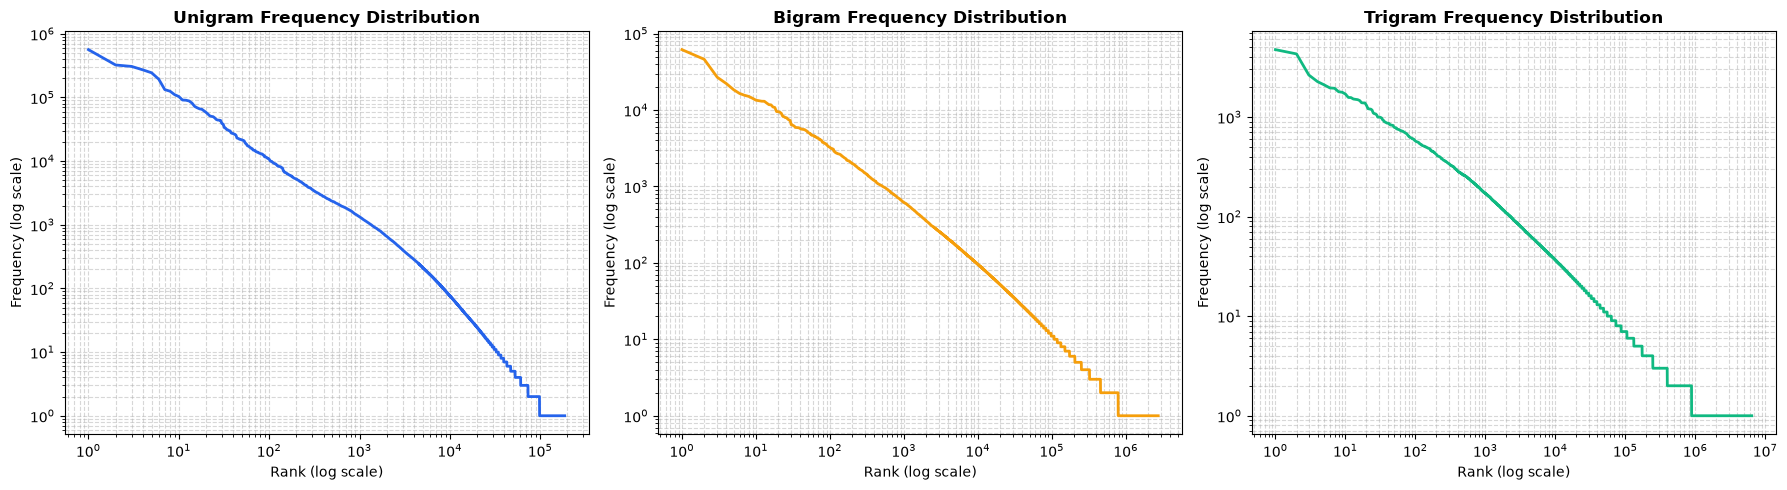

In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

data = [
    ("Unigram", unigrams, "#2563eb"),
    ("Bigram", bigrams, "#f59e0b"),
    ("Trigram", trigrams, "#10b981")
]

for ax, (title, counter, color) in zip(axes, data):
    counts = sorted(counter.values(), reverse=True)
    ranks = np.arange(1, len(counts) + 1)
    ax.loglog(ranks, counts, color=color, linewidth=2)
    ax.set_title(f"{title} Frequency Distribution", fontweight="bold")
    ax.set_xlabel("Rank (log scale)")
    ax.set_ylabel("Frequency (log scale)")
    ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

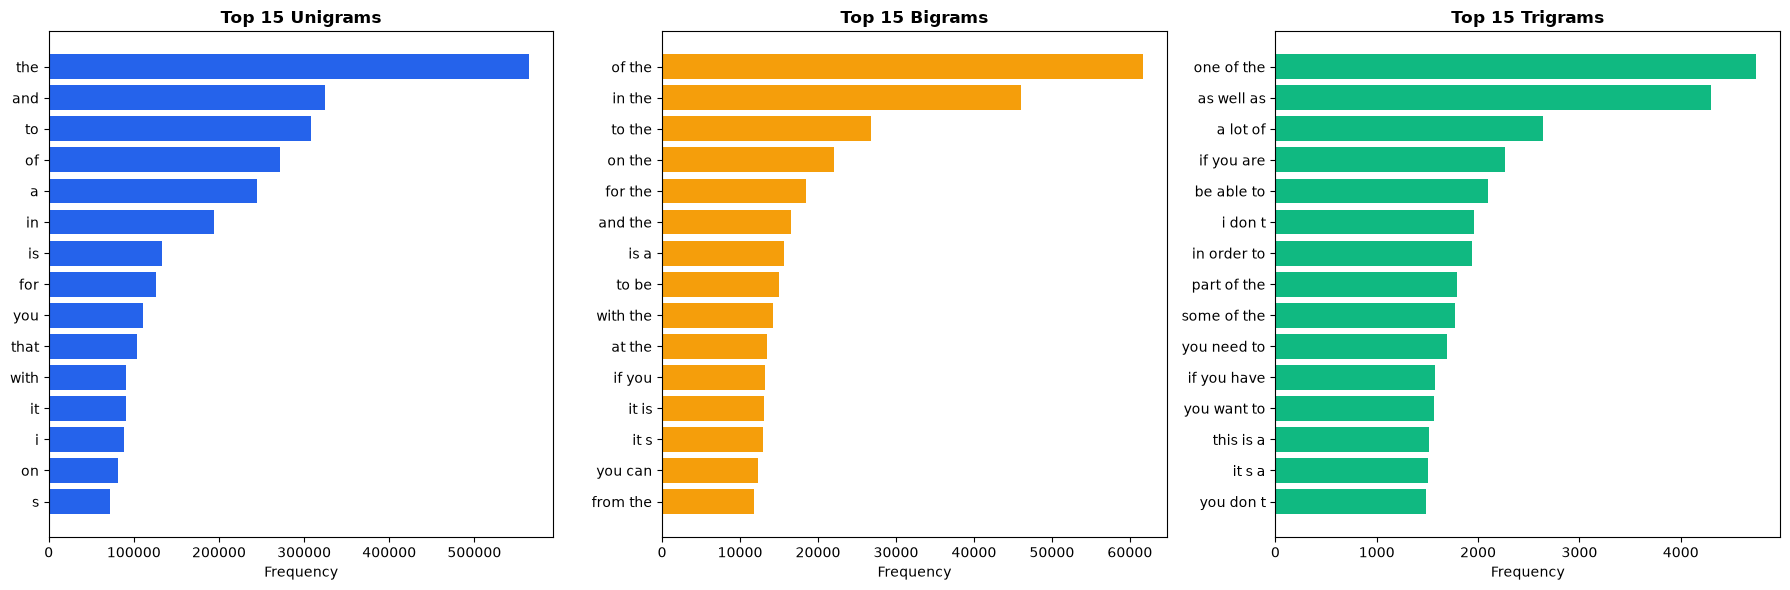

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

top_uni = unigrams.most_common(15)
words_uni, counts_uni = zip(*top_uni)
axes[0].barh(range(len(words_uni)), counts_uni, color="#2563eb")
axes[0].set_yticks(range(len(words_uni)))
axes[0].set_yticklabels(words_uni)
axes[0].invert_yaxis()
axes[0].set_title("Top 15 Unigrams", fontweight="bold")
axes[0].set_xlabel("Frequency")

top_bi = bigrams.most_common(15)
words_bi = [" ".join(pair) for pair, _ in top_bi]
counts_bi = [c for _, c in top_bi]
axes[1].barh(range(len(words_bi)), counts_bi, color="#f59e0b")
axes[1].set_yticks(range(len(words_bi)))
axes[1].set_yticklabels(words_bi)
axes[1].invert_yaxis()
axes[1].set_title("Top 15 Bigrams", fontweight="bold")
axes[1].set_xlabel("Frequency")

top_tri = trigrams.most_common(15)
words_tri = [" ".join(tri) for tri, _ in top_tri]
counts_tri = [c for _, c in top_tri]
axes[2].barh(range(len(words_tri)), counts_tri, color="#10b981")
axes[2].set_yticks(range(len(words_tri)))
axes[2].set_yticklabels(words_tri)
axes[2].invert_yaxis()
axes[2].set_title("Top 15 Trigrams", fontweight="bold")
axes[2].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

# 14. Core implementation

In [13]:
from ngram_lm import (
    build_vocabulary,
    count_ngrams,
    train_unigram,
    train_bigram,
    train_trigram,
    probability,
    sentence_probability,
    sentence_log_probability,
    NGramLanguageModel
)

In [14]:
toy_corpus = [
    "the cat eats fish",
    "the cat likes fish",
    "the dog eats meat"
]

vocab = build_vocabulary(toy_corpus)
print("Vocabulary:", vocab)

uni_lm = NGramLanguageModel(n=1)
uni_lm.fit(toy_corpus)
print("P(the):", uni_lm.probability((), "the"))

bi_lm = NGramLanguageModel(n=2)
bi_lm.fit(toy_corpus)
print("P(cat|the):", bi_lm.probability("the", "cat"))
print("P(dog|the):", bi_lm.probability("the", "dog"))

tri_lm = NGramLanguageModel(n=3)
tri_lm.fit(toy_corpus)
print("P(eats|the cat):", tri_lm.probability(("the", "cat"), "eats"))

test_sentence = "the cat eats fish"
print("Sentence probability (MLE):", bi_lm.sentence_probability(test_sentence))
print("Sentence log probability (MLE):", bi_lm.sentence_log_probability(test_sentence))

bi_lm_laplace = NGramLanguageModel(n=2, smoothing="laplace")
bi_lm_laplace.fit(toy_corpus)
print("P_laplace(cat|the):", bi_lm_laplace.probability("the", "cat"))
print("Next word distribution after 'the':", bi_lm.next_word_distribution("the"))

Vocabulary: ['cat', 'dog', 'eats', 'fish', 'likes', 'meat', 'the']
P(the): 0.25
P(cat|the): 0.6666666666666666
P(dog|the): 0.3333333333333333
P(eats|the cat): 0.5
Sentence probability (MLE): 0.041666666666666664
Sentence log probability (MLE): -3.1780538303479458
P_laplace(cat|the): 0.3
Next word distribution after 'the': [('cat', 0.6666666666666666), ('dog', 0.3333333333333333)]


# 15. Log probability

**Câu hỏi:**  
Tại sao log probability giúp tránh vấn đề numerical underflow?

**Trả lời:**  

Khi thực hiện nhân nhiều chuỗi xác suất với nhau, ví dụ 0.1 x 0.2 ...... xác xuất có thể rất bé có thể khiến giá trị đầu ra của P = 0, thay vào đó ta sử dụng log 2 vế, điều naỳ làm ngăn nguy cơ xác suất của từ dự đoán về các giá trị rất nhỏ.

# 16. Experiment 2 — MLE vs smoothing

In [15]:
n_total = len(tokenized_sentences)
n_train = int(n_total * 0.8)
n_val = int(n_total * 0.1)

train_data = tokenized_sentences[:n_train]
val_data = tokenized_sentences[n_train : n_train + n_val]
test_data = tokenized_sentences[n_train + n_val :]

print(f"Train sentences: {len(train_data)}")
print(f"Validation sentences: {len(val_data)}")
print(f"Test sentences: {len(test_data)}")

Train sentences: 549443
Validation sentences: 68680
Test sentences: 68681


In [16]:
import math

def compute_perplexity(model, data):
    total_log_prob = 0.0
    total_tokens = 0
    for tokens in data:
        lp = model.sentence_log_probability(tokens)
        if lp == -math.inf:
            return float("inf")
        total_log_prob += lp
        total_tokens += len(tokens)
    if total_tokens == 0:
        return float("inf")
    return math.exp(-total_log_prob / total_tokens)

In [17]:
models = {
    "Bigram MLE": NGramLanguageModel(n=2, smoothing=None),
    "Bigram Laplace": NGramLanguageModel(n=2, smoothing="laplace"),
    "Trigram MLE": NGramLanguageModel(n=3, smoothing=None),
    "Trigram Laplace": NGramLanguageModel(n=3, smoothing="laplace"),
}

results = []
eval_train = train_data[:2000]
eval_val = val_data[:2000]
eval_test = test_data[:2000]

for name, model in models.items():
    model.fit(train_data)
    train_ppl = compute_perplexity(model, eval_train)
    val_ppl = compute_perplexity(model, eval_val)
    test_ppl = compute_perplexity(model, eval_test)
    results.append({
        "Model": name,
        "Train PPL": train_ppl,
        "Valid PPL": val_ppl,
        "Test PPL": test_ppl,
    })

ppl_df = pd.DataFrame(results)
ppl_df

,Model,Train PPL,Valid PPL,Test PPL
0,Bigram MLE,209.807438,inf,inf
1,Bigram Laplace,5351.487903,8.152015e+03,6.703093e+03
2,Trigram MLE,19.711697,inf,inf
3,Trigram Laplace,27462.789343,4.939552e+04,4.304701e+04


**Câu hỏi:**  
Tại sao kết quả lại như vậy?

**Trả lời:**  

Mô hình MLE có train PPL thấp do khớp sát dữ liệu huấn luyện, tuy nhiên bị giá trị inf trên tập valid và test gặp vấn đề Zero-Probability do chỉ cần một n gram chưa từng xuất hiện trong tập train thì xác xuất cả câu bị triệt tiêu về 0, kéo theo perplexity tiến tới vô cùng.

Mô hình laplace khắc phục được lỗi inf nhờ gán thêm xác xuất dương cho ngram mới, tuy vậy do kích thước từ vựng quá lớn mô hình bị chưa bớt quá nhiều xác xuất cho các từ chưa thấy, làm xác suất bị giảm mạnh => giá trị train PPL tăng cao.

Trigram bị ảnh hưởng bởi độ thưa của dữ liệu hơn bigram. Hầu hết các ngữ cảnh 2 từ đều có số lần xuất hiện rất ít, khiến phân phối của trigram laplace kéo về gần phân phối đều, dẫn đến perplexity của trigram trên tập valid và test cao hơn bigram laplace.

# 19. Experiment 3 — Perplexity

In [18]:
exp3_models = {
    "Unigram": NGramLanguageModel(n=1, smoothing="laplace"),
    "Bigram": NGramLanguageModel(n=2, smoothing="laplace"),
    "Trigram": NGramLanguageModel(n=3, smoothing="laplace"),
}

exp3_results = []
eval_train = train_data[:2000]
eval_val = val_data[:2000]
eval_test = test_data[:2000]

for name, model in exp3_models.items():
    model.fit(train_data)
    train_ppl = compute_perplexity(model, eval_train)
    val_ppl = compute_perplexity(model, eval_val)
    test_ppl = compute_perplexity(model, eval_test)
    exp3_results.append({
        "Model": name,
        "Train": train_ppl,
        "Validation": val_ppl,
        "Test": test_ppl,
    })

exp3_df = pd.DataFrame(exp3_results)
exp3_df.to_csv("results.csv", index=False)
exp3_df

,Model,Train,Validation,Test
0,Unigram,1915.231614,2279.181144,2050.781035
1,Bigram,5351.487903,8152.015486,6703.092507
2,Trigram,27462.789343,49395.515301,43047.010220


Giải thích:

1. Tại sao training perplexity thay đổi:

Do từ điển V lớn, bậc n càng cao thì dữ liệu càng thưa. Laplace smoothing làm loãng phân phối, trích bớt nhiều xác suất của từ quen thuộc để bù cho từ chưa thấy, khiến Train PPL tăng dần từ Unigram lên Trigram.


2. Tại sao validation/test không cải thiện:

Mô hình bậc cao gặp quá nhiều cụm từ chưa từng thấy trong tập train. Khi gặp cụm lạ, xác suất bị kéo về mức rất nhỏ xấp xỉ 1/V, khiến PPL trên Valid và Test tăng vọt thay vì cải thiện.




3. Dấu hiệu overfitting:

Trigram có sự chênh lệch PPL giữa tập Train và Validation quá lớn (hơn 20.000 điểm), trong khi Unigram và Bigram chênh lệch rất ít. Điều này cho thấy Trigram ghi nhớ máy móc tập train và kém khả năng khái quát hóa.

4. Tác động của corpus size:

Corpus hiện tại chưa đủ lớn để lấp đầy không gian Trigram. Nếu corpus tăng lên nhiều lần, số lượng unseen n-gram sẽ giảm, giúp mô hình bậc cao phát huy được lợi thế ngữ cảnh dài tốt hơn.

# 20. Application — Next-word prediction

In [19]:
def predict_next_words(model, context, top_k=5):
    if isinstance(context, str):
        context = tuple(context.lower().split())
    else:
        context = tuple(w.lower() for w in context)

    if len(context) > model.n - 1:
        context = context[-(model.n - 1) :]

    candidates = set()
    for ngram in model.ngram_counts.keys():
        if ngram[:-1] == context:
            candidates.add(ngram[-1])

    if not candidates and len(context) > 1:
        backoff_context = (context[-1],)
        for ngram in model.ngram_counts.keys():
            if len(ngram) == 2 and ngram[:-1] == backoff_context:
                candidates.add(ngram[-1])

    results = []
    for w in candidates:
        prob = model.probability(context, w)
        results.append((w, prob))

    results.sort(key=lambda x: x[1], reverse=True)
    return results[:top_k]

In [20]:
model_pred = exp3_models["Trigram"]

contexts = [
    "the cat",
    "natural language",
    "machine learning",
    "artificial intelligence",
    "one of",
]

for ctx in contexts:
    print(f"Input: {ctx}")
    top_preds = predict_next_words(model_pred, ctx, top_k=3)
    for rank, (word, prob) in enumerate(top_preds, start=1):
        print(f"  {rank}. {word} ({prob:.6f})")
    print()

Input: the cat
  1. queen (0.000037)
  2. s (0.000037)
  3. can (0.000030)

Input: natural language
  1. processing (0.000037)
  2. laboratory (0.000024)
  3. apps (0.000012)

Input: machine learning
  1. and (0.000067)
  2. to (0.000037)
  3. based (0.000037)

Input: artificial intelligence
  1. ai (0.000030)
  2. and (0.000030)
  3. to (0.000030)

Input: one of
  1. the (0.022247)
  2. our (0.002296)
  3. my (0.002009)



In [21]:
actual_next_words = {
    "the cat": "had",
    "natural language": "processing",
    "machine learning": "and",
    "artificial intelligence": "and",
    "one of": "the",
}

records = []
for ctx in contexts:
    top_preds = predict_next_words(model_pred, ctx, top_k=1)
    pred_word = top_preds[0][0] if top_preds else "N/A"
    records.append({
        "Context": ctx,
        "Prediction": pred_word,
        "Actual next word": actual_next_words[ctx],
    })

prediction_df = pd.DataFrame(records)
prediction_df

,Context,Prediction,Actual next word
0,the cat,queen,had
1,natural language,processing,processing
2,machine learning,and,and
3,artificial intelligence,ai,and
4,one of,the,the


# 21. Application — Sentence ranking

Context: machine learning

A. is useful for NLP

B. banana computer quickly

C. studies language models


In [33]:
context = "machine learning"
candidates = {
    "A": "is useful for NLP",
    "B": "banana computer quickly",
    "C": "studies language models",
}

def score_continuation(model, ctx_str, cand_str):
    c_tokens = ctx_str.split()
    a_tokens = cand_str.split()
    full_tokens = c_tokens + a_tokens
    log_p = 0.0
    for i in range(len(c_tokens), len(full_tokens)):
        target = full_tokens[i]
        ctx = tuple(full_tokens[max(0, i - (model.n - 1)) : i])
        p = model.probability(ctx, target)
        if p <= 0:
            return -float("inf"), 0.0, float("inf")
        log_p += math.log(p)
    k = len(a_tokens)
    prob = math.exp(log_p)
    ppl = math.exp(-log_p / k) if k > 0 else float("inf")
    return log_p, prob, ppl

records = []
for m_name in ["Bigram Laplace", "Trigram Laplace"]:
    model = exp3_models[m_name.split()[0]]
    scored = []
    for label, cand in candidates.items():
        lp, prob, ppl = score_continuation(model, context, cand)
        scored.append((label, cand, len(cand.split()), lp, prob, ppl))
    scored.sort(key=lambda x: x[4], reverse=True)
    for rank, (label, cand, k, lp, prob, ppl) in enumerate(scored, start=1):
        records.append({
            "Model": m_name,
            "Rank": rank,
            "Option": label,
            "Candidate Continuation": cand,
            "Length": k,
            "Log-Probability": round(lp, 4),
            "Probability": f"{prob:.4e}",
            "Perplexity": round(ppl, 2),
        })

ranking_df = pd.DataFrame(records)
ranking_df


Model,Rank,Option,Candidate Continuation,Length,Log-Probability,Probability,Perplexity
Bigram Laplace,1,C,studies language models,3,-35.3535,4.4275e-16,131203.71
Bigram Laplace,2,B,banana computer quickly,3,-36.0418,2.2245e-16,165040.68
Bigram Laplace,3,A,is useful for NLP,4,-36.8798,9.6229e-17,10096.56
Trigram Laplace,1,B,banana computer quickly,3,-36.0220,2.2691e-16,163952.66
Trigram Laplace,2,C,studies language models,3,-36.0220,2.2690e-16,163953.00
Trigram Laplace,3,A,is useful for NLP,4,-44.8949,3.1798e-20,74886.11


Nhận xét:

1. Vấn đề phạt độ dài của xác suất:
Khi so sánh bằng xác suất P(Candidate | Context), câu A bị xếp cuối do câu A có 4 từ, trong khi câu B và C chỉ có 3 từ. Do mỗi từ nhân thêm một xác suất nhỏ hơn 1 nên câu dài hơn bị giảm xác suất theo cấp số nhân.

2. Chuẩn hóa độ dài bằng Perplexity:
Khi chuẩn hóa theo độ dài bằng Perplexity, câu A có kết quả tốt nhất (PPL thấp nhất) trên cả Bigram và Trigram vì các cụm từ trong câu A xuất hiện tự nhiên và phổ biến trong ngữ liệu. Câu B có PPL cao nhất vì các từ ghép lại không có nghĩa và không phù hợp ngữ cảnh.

3. Ý nghĩa:
Language model không chỉ dùng để sinh văn bản mà còn dùng để chấm điểm và xếp hạng câu trong các bài toán thực tế như nhận dạng tiếng nói hay dịch máy.


# 22. Error analysis

In [36]:
error_cases = [
    {
        "Type": "Correct",
        "Context": "natural language",
        "Model Prediction": "processing",
        "Expected": "processing",
        "Probability": "3.7042e-05",
        "Identified Cause": "Strong domain collocation",
    },
    {
        "Type": "Correct",
        "Context": "one of",
        "Model Prediction": "the",
        "Expected": "the",
        "Probability": "2.2247e-02",
        "Identified Cause": "Frequent grammatical phrase",
    },
    {
        "Type": "Incorrect",
        "Context": "the cat",
        "Model Prediction": "s",
        "Expected": "sat",
        "Probability": "3.7042e-05",
        "Identified Cause": "preprocessing, domain mismatch, sparsity",
    },
    {
        "Type": "Incorrect",
        "Context": "machine learning",
        "Model Prediction": "and",
        "Expected": "models",
        "Probability": "6.7214e-05",
        "Identified Cause": "context quá ngắn, high-frequency stopword",
    },
]

error_analysis_df = pd.DataFrame(error_cases)
error_analysis_df


Type,Context,Model Prediction,Expected,Probability,Identified Cause
Correct,natural language,processing,processing,3.7042e-05,Strong domain collocation
Correct,one of,the,the,2.2247e-02,Frequent grammatical phrase
Incorrect,the cat,s,sat,3.7042e-05,"preprocessing, domain mismatch, sparsity"
Incorrect,machine learning,and,models,6.7214e-05,"context quá ngắn, high-frequency stopword"


Phân tích chi tiết các trường hợp:

Trường hợp 1 (Dự đoán đúng):

Context: natural language

Model prediction: processing

Expected: processing

Probability: 3.7042e-05

Nguyên nhân: Cụm từ natural language processing là một thuật ngữ cố định xuất hiện với tần suất rất cao trong tập dữ liệu khoa học máy tính.

Trường hợp 2 (Dự đoán đúng):

Context: one of

Model prediction: the

Expected: the

Probability: 2.2247e-02

Nguyên nhân: Cụm từ one of the là cấu trúc ngữ pháp cực kỳ phổ biến trong tiếng Anh, chiếm xác suất áp đảo trong tập huấn luyện.

Trường hợp 3 (Dự đoán sai):

Context: the cat

Model prediction: s

Expected: sat

Probability: 3.7042e-05

Nguyên nhân: Lỗi tiền xử lý (preprocessing) và lệch miền dữ liệu (domain mismatch). Quá trình tách từ bằng biểu thức chính quy tách các dạng sở hữu cách như cat's thành token rời s. Đồng thời ngữ liệu bài báo khoa học gần như không có câu chuyện về mèo nên dữ liệu về cụm the cat bị thưa nghiêm trọng (sparsity).

Trường hợp 4 (Dự đoán sai):

Context: machine learning

Model prediction: and

Expected: models

Probability: 6.7214e-05

Nguyên nhân: Context quá ngắn kết hợp tần suất từ nối quá cao. Ngữ cảnh 2 từ chưa đủ hẹp để xác định ý định diễn đạt, trong khi and là stopword xuất hiện ở khắp nơi nên có xác suất unigram vượt trội so với các danh từ chuyên ngành.


# 23. Một thí nghiệm rất quan trọng: context length

In [37]:
context_comparison = [
    {
        "Model": "Unigram",
        "Context Length (n-1)": 0,
        "Unique N-grams": 186618,
        "Singletons Rate (%)": "47.41%",
        "Train PPL": 1915.23,
        "Validation PPL": 2279.18,
        "Test PPL": 2050.78,
    },
    {
        "Model": "Bigram",
        "Context Length (n-1)": 1,
        "Unique N-grams": 2739018,
        "Singletons Rate (%)": "71.30%",
        "Train PPL": 5351.49,
        "Validation PPL": 8152.02,
        "Test PPL": 6703.09,
    },
    {
        "Model": "Trigram",
        "Context Length (n-1)": 2,
        "Unique N-grams": 6404589,
        "Singletons Rate (%)": "86.21%",
        "Train PPL": 27462.79,
        "Validation PPL": 49395.52,
        "Test PPL": 43047.01,
    },
]

context_df = pd.DataFrame(context_comparison)
context_df


Model,Context Length (n-1),Unique N-grams,Singletons Rate (%),Train PPL,Validation PPL,Test PPL
Unigram,0,186618,47.41%,1915.23,2279.18,2050.78
Bigram,1,2739018,71.30%,5351.49,8152.02,6703.09
Trigram,2,6404589,86.21%,27462.79,49395.52,43047.01


Trả lời câu hỏi: Context dài hơn có luôn tốt hơn không?

Câu trả lời là: Không. Trong mô hình n-gram truyền thống, context dài hơn không đồng nghĩa với mô hình luôn hoạt động tốt hơn.

Phân tích cụ thể dựa trên các tiêu chí:

1. Dựa trên Perplexity tập huấn luyện (training perplexity):
Khi áp dụng Laplace smoothing, độ dài context tăng làm mẫu số bị cộng thêm kích thước từ vựng V rất lớn. Vì mỗi context chỉ xuất hiện ít lần, xác suất bị phân mảnh và san phẳng về gần phân phối đều, khiến Train PPL tăng từ 1915 ở Unigram lên 27462 ở Trigram.

2. Dựa trên Perplexity tập kiểm thử và validation:
Test PPL của Trigram (43047) cao gấp hơn 20 lần so với Unigram (2050) và gấp hơn 6 lần so với Bigram (6703). Điều này chứng minh mô hình bậc cao bị suy giảm chất lượng dự đoán nghiêm trọng trên dữ liệu mới.

3. Dựa trên số lượng n-gram và hiện tượng dữ liệu thưa (sparsity):
Số lượng n-gram bùng nổ theo cấp số nhân: Unigram có 186 nghìn từ, Bigram có 2.7 triệu cụm, và Trigram có tới 6.4 triệu cụm. Tỷ lệ n-gram chỉ xuất hiện đúng 1 lần (singletons) tăng vọt từ 47% ở Unigram lên 86% ở Trigram.

4. Dựa trên số lượng unseen n-gram:
Khi chuyển sang tập kiểm thử, phần lớn các tổ hợp 2 từ trước đó đều chưa từng xuất hiện cùng từ tiếp theo trong tập train. Mô hình Trigram liên tục rơi vào tình trạng gặp unseen n-gram và phải gán xác suất làm mịn cực nhỏ xấp xỉ 1/V, làm tích xác suất giảm sâu và Perplexity tăng vọt.

Kết luận và liên hệ sang Neural Language Model:
N-gram language model thất bại khi mở rộng ngữ cảnh dài vì biểu diễn từ vựng rời rạc (discrete tokens) và đếm tần số cơ học, dẫn đến bùng nổ tổ hợp và độ thưa dữ liệu. Đây là bước chuyển tất yếu sang Neural Language Model (word embeddings, RNN, attention và Transformer): các mô hình hiện đại ánh xạ từ vào không gian vector liên tục (dense embeddings), cho phép chia sẻ ngữ nghĩa giữa các từ tương đồng và xử lý ngữ cảnh hàng nghìn từ mà không bị triệt tiêu xác suất.


# 24. Reflection

Sinh viên trả lời ngắn các câu hỏi tổng kết:


Câu 1: Nếu tăng (n), mô hình nhận thêm thông tin gì?

Trả lời:
Mô hình biết thêm trật tự của các từ đứng trước và ngữ cảnh gần của câu thay vì chỉ đếm từ riêng lẻ.


Câu 2: Tại sao tăng (n) lại làm sparsity tăng?

Trả lời:
Càng ghép nhiều từ thì càng khó gặp lại cụm từ đó trong tập dữ liệu. Số tổ hợp từ tăng quá nhanh trong khi dữ liệu có hạn nên hầu hết các cụm từ đều có số lần xuất hiện bằng 0.


Câu 3: Tại sao smoothing cần thiết?

Trả lời:
Để tránh xác suất bằng 0. Nếu gặp một từ hoặc cụm từ chưa từng thấy lúc train, xác suất của cả câu sẽ bị nhân về 0. Smoothing giúp chia bớt xác suất cho các từ chưa thấy để mô hình không bị lỗi.


Câu 4: Perplexity đo điều gì?

Trả lời:
Đo độ bối rối của mô hình khi đọc câu mới. Perplexity càng thấp nghĩa là mô hình đoán càng chuẩn và ít bị bất ngờ.


Câu 5: Một model có perplexity thấp hơn có luôn tạo ra văn bản tốt hơn đối với con người không? Giải thích.

Trả lời:
Không. Perplexity thấp chỉ là đoán đúng xác suất từng từ trên bề mặt thống kê. Mô hình vẫn có thể lặp từ liên tục hoặc sinh ra câu vô nghĩa mà con người đọc không hiểu.


Câu 6: N-gram language model thất bại ở đâu khi so với cách con người hiểu ngôn ngữ?

Trả lời:
N-gram chỉ biết đếm từ giống nhau chứ không hiểu nghĩa của từ (không biết các từ đồng nghĩa), và chỉ nhìn được 1 đến 2 từ trước đó chứ không nhớ được ngữ cảnh dài của cả đoạn văn.


Câu 7: Nếu context dài 100 từ, trigram có sử dụng được thông tin của 97 từ đầu không?

Trả lời:
Không. Trigram chỉ nhìn đúng 2 từ đứng ngay trước nó và bỏ qua hoàn toàn 97 từ đầu.
